# Analysis of memory-pool simulations

## Set up

In [1]:
suppressMessages({
    require(RColorBrewer, quietly=TRUE)
    require(data.table, quietly=TRUE)
    require(ggplot2, quietly=TRUE)
    require(ggraph, quietly=TRUE)
    require(igraph, quietly=TRUE)
    require(magrittr, quietly=TRUE)
    require(tidygraph, quietly=TRUE)
})

## Adversarial nodes, with 2 ms delay for front-running and at 6 TPS

### Read data

In [2]:
adversaries <- fread("adversaries.tsv.gz", stringsAsFactors=TRUE)
adversaries[, `Honest txs`:=`RB honest txs`+`EB honest txs`]
adversaries[, `Adversarial txs`:=`RB adversarial txs`+`EB adversarial txs`]
adversaries[, `Txs`:=`Honest txs`+`Adversarial txs`]
adversaries %>% summary

 Adversarial nodes     RB ID      RB honest txs   RB adversarial txs
 Min.   :  0.0     B0     : 101   Min.   : 0.00   Min.   :0.000000  
 1st Qu.:125.0     B1     : 101   1st Qu.: 0.00   1st Qu.:0.000000  
 Median :245.0     B2     : 101   Median :35.50   Median :0.000000  
 Mean   :247.6     B3     : 101   Mean   :30.46   Mean   :0.009249  
 3rd Qu.:368.8     B4     : 101   3rd Qu.:60.00   3rd Qu.:0.000000  
 Max.   :500.0     B5     : 101   Max.   :60.00   Max.   :2.000000  
                   (Other):1124                                     
     EB ID      EB honest txs     EB adversarial txs   Honest txs    
        :1037   Min.   :   0.00   Min.   : 0.0000    Min.   :   0.0  
 EB3    :  55   1st Qu.:   0.00   1st Qu.: 0.0000    1st Qu.:  60.0  
 EB1    :  54   Median :   0.00   Median : 0.0000    Median :  60.0  
 EB2    :  54   Mean   :  71.94   Mean   : 0.3595    Mean   : 102.4  
 EB4    :  53   3rd Qu.:  83.00   3rd Qu.: 0.0000    3rd Qu.:  83.0  
 EB6    :  49   Max.   :1367

### Raw data at the block level

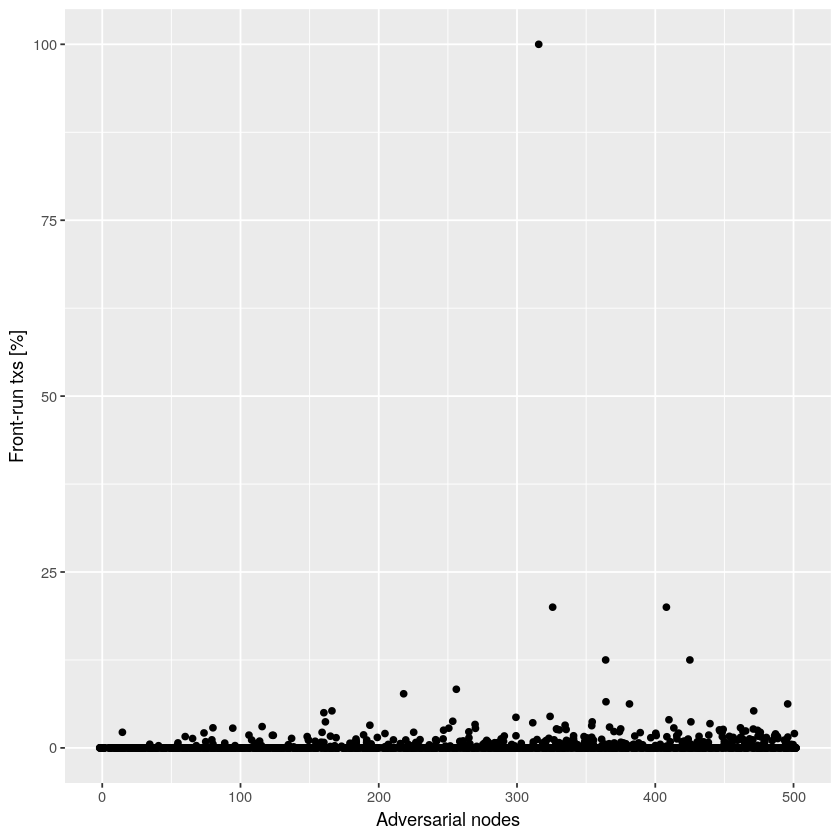

In [3]:
ggplot(
    adversaries[
        `Txs` > 0,
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Adversarial nodes`, `RB ID`)
    ], 
    aes(x=`Adversarial nodes`, y=`Front-run txs [%]`)
) +
    geom_jitter()

### Trends

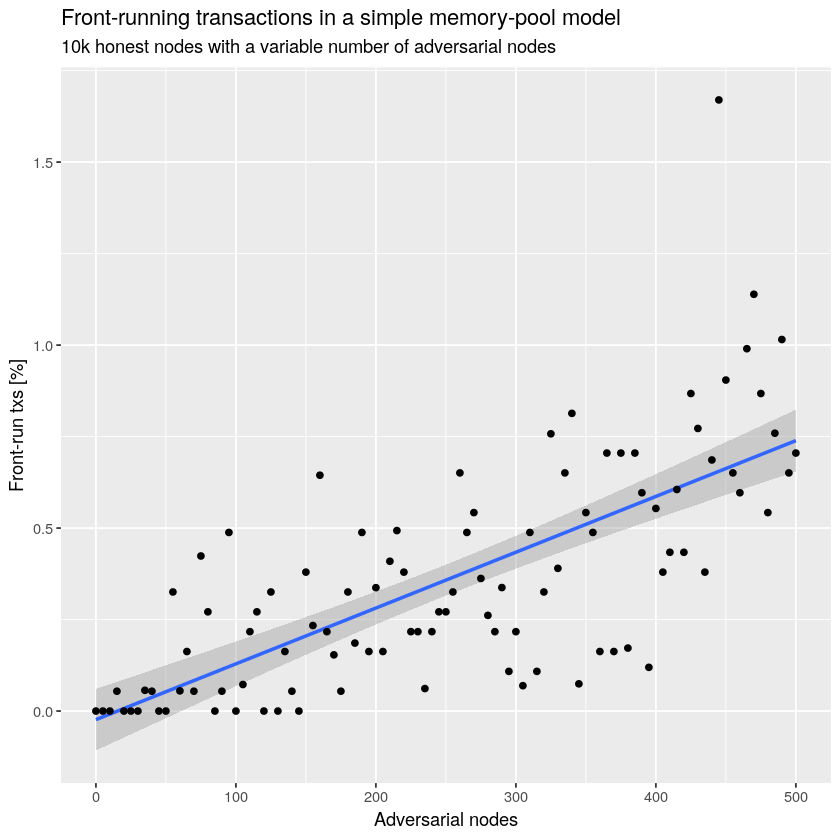

In [4]:
ggplot(
    adversaries[
        ,
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Adversarial nodes`)
    ], 
    aes(x=`Adversarial nodes`, y=`Front-run txs [%]`)
) +
    geom_smooth(formula=y~x, method="lm") +
    geom_point() +
    ggtitle(
        "Front-running transactions in a simple memory-pool model",
        "10k honest nodes with a variable number of adversarial nodes"
    )

In [5]:
ggsave("adversarial-scatter-2ms-delay.png", units="in", dpi=150, width=8, height=6)

In [6]:
ggsave("adversarial-scatter-2ms-delay.svg", units="in", dpi=150, width=8, height=6)

### Regression model

In [7]:
lm(
    `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`,
    data=adversaries[
        ,
        .(`Front-run txs [%]`=100*sum(`Adversarial txs`)/sum(`Txs`)),
        .(`Fraction adversarial nodes [%]`=100*`Adversarial nodes`/(10000+`Adversarial nodes`))
    ]
) %>% summary


Call:
lm(formula = `Front-run txs [%]` ~ `Fraction adversarial nodes [%]`, 
    data = adversaries[, .(`Front-run txs [%]` = 100 * sum(`Adversarial txs`)/sum(Txs)), 
        .(`Fraction adversarial nodes [%]` = 100 * `Adversarial nodes`/(10000 + 
            `Adversarial nodes`))])

Residuals:
     Min       1Q   Median       3Q      Max 
-0.45876 -0.12876 -0.01565  0.11821  1.01809 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -0.02863    0.04320  -0.663    0.509    
`Fraction adversarial nodes [%]`  0.15971    0.01549  10.311   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2161 on 99 degrees of freedom
Multiple R-squared:  0.5178,	Adjusted R-squared:  0.513 
F-statistic: 106.3 on 1 and 99 DF,  p-value: < 2.2e-16


So, unlike in the pure Praos case, the fraction of front-run transactions is significantly smaller thanthe fraction of adversarial nodes.